# The Mandelbrot set

The Mandelbrot set is defined as the set of complex numbers $c$ for which the iterative sequence: 
$z_{n+1} = z_n^2 + c$

with $z_0 = 0$, remains bounded (doesn't diverge to infinity) which we define as, $|z_{n+1}| \leq 2$ for all $n$.

So the first interations of the sequence looks like this.
$z_0 = 0$   
$z_1 = 0 + c = c$   
$z_2 = c² + c$  
$z_3 = (c²+c)² + c$     
...

## The naive approach in Python
When calculating all the values in the Mandelbrot set, one could take a naive approach. Disregarding any optimization choices and use default python lists and nested for loops:

In [18]:
# Define the limits and parameters for the mandelbrot set.
# The typical view (limits) as defined by the problem description from moodle.
x_min = -2.0 
x_max =  1.0
y_min = -1.5
y_max =  1.5

# Minimum resolution to start with. Will be updated later to test scalability.
width = 1024
height = 1024

# Larger max_iterations than suggested in moodle (1000 instead of 100) to help emphisize the difference between solution.
max_iterations = 1000


def mandelbrot(c, max_iterations):
    z = 0
    n = 0

    # Keep interating as long as the magnitude of z is less than or equal to 2 (doesn't diverge to infinity) and we haven't reached the maximum number of iterations.
    while abs(z) <= 2.0 and n < max_iterations:
        z = z*z + c
        n += 1
    return n


def generate_mandelbrot_set_naive():

    # Create a naive 2D list to hold the values.
    mandelbrot_set = [[0 for _ in range(width)] for _ in range(height)]

    # Loop through all pixels and determine how many iterations it takes for the corresponding magnitude to become greater than 2 (indicating divergence to infinity).
    for y in range(height):
        for x in range(width):
            real = x_min + (x / width) * (x_max - x_min)
            imag = y_min + (y / height) * (y_max - y_min)
            c = complex(real, imag)
            mandelbrot_set[y][x] = mandelbrot(c, max_iterations)

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_naive = generate_mandelbrot_set_naive()
%timeit generate_mandelbrot_set_naive()


11.8 s ± 50 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


As we can see the naive approach results in each function call taking multiple seconds to complete at this scale (1024 x 1024).

Using a colorbar plot we can visualize the set and confirm that we get the expected result:

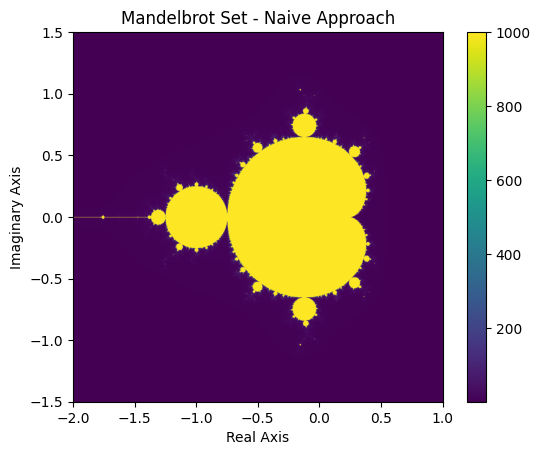

In [19]:
import matplotlib.pyplot as plt

# Plotting the set using colorbar.
plt.imshow(mandelbrot_set_naive, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - Naive Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()

## Vectorized approach in Python using NumPy
Now that we have tried the naive approach we can start thinking about ways to optimize the approach. - and as listed by the problem description the first option that we try to implement is a vectorized approach.

In the vectorized approach we try to limit the amount of loops by replacing the (looped) interations with calculations that can be done simultaneously with vector operations:

In [20]:
import numpy as np

def generate_mandelbrot_set_vectorized():

    # Create a 2D array of complex numbers representing the points in the complex plane.
    real = np.linspace(x_min, x_max, width)
    imag = np.linspace(y_min, y_max, height)

    # Define all the complex numbers in the grid.
    c = np.array([[complex(r, i) for r in real] for i in imag])

    # Initialize an array to hold the number of iterations for each point.
    mandelbrot_set = np.zeros(c.shape, dtype=int)

    # Create an array to hold the current values of z for each point.
    z = np.zeros(c.shape, dtype=complex)

    # Iterate up to max_iterations times, updating all points simultaneously using vectorized operations.
    for n in range(max_iterations):
        mask = np.abs(z) <= 2.0  # Only update points that haven't diverged (magnitude <= 2).
        z[mask] = z[mask] * z[mask] + c[mask]  # Update z for those points.
        mandelbrot_set[mask] = n  # Update the iteration count for those points.

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_vectorized = generate_mandelbrot_set_vectorized()
%timeit generate_mandelbrot_set_vectorized()

1.73 s ± 15.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


And now we see that a function call takes just shy of 2 seconds to complete at the same scale (1024 x 1024).

Again, we can use a colorbar plot we can visualize the set and confirm that we get the expected result:

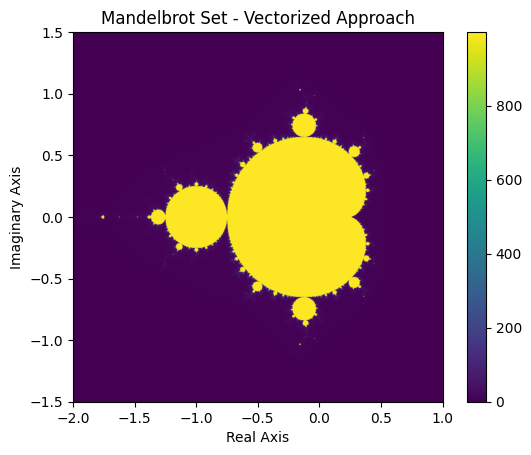

In [21]:
# Plotting the new set using colorbar.
plt.imshow(mandelbrot_set_vectorized, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - Vectorized Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()

## Precompiled approach using Numba and JIT (Just In Time compilation)
Now that we have tried to optimize the approach using vector calculations, we can also try to just let the compiler optimize for us using JIT. -Specifically numba.jit():

In [22]:
import numba

@numba.jit(nopython=True)
def generate_mandelbrot_set_jit():


    # Define helper function here to avoid numba issues with nested functions.
    def mandelbrot(c, max_iterations):
        z = 0
        n = 0

        # Keep interating as long as the magnitude of z is less than or equal to 2 (doesn't diverge to infinity) and we haven't reached the maximum number of iterations.
        while abs(z) <= 2.0 and n < max_iterations:
            z = z*z + c
            n += 1
        return n

    # Create a naive 2D list to hold the values.
    mandelbrot_set = [[0 for _ in range(width)] for _ in range(height)]

    # Loop through all pixels and determine how many iterations it takes for the corresponding magnitude to become greater than 2 (indicating divergence to infinity).
    for y in range(height):
        for x in range(width):
            real = x_min + (x / width) * (x_max - x_min)
            imag = y_min + (y / height) * (y_max - y_min)
            c = complex(real, imag)
            mandelbrot_set[y][x] = mandelbrot(c, max_iterations)

    # Return interation counts for each complex number.
    return mandelbrot_set

mandelbrot_set_jit = generate_mandelbrot_set_jit()
%timeit generate_mandelbrot_set_jit()

722 ms ± 2.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


And here se see even more improvement compared to the naive approach. -eventhough we just compiled it.

Again, we can use a colorbar plot we can visualize the set and confirm that we get the expected result:

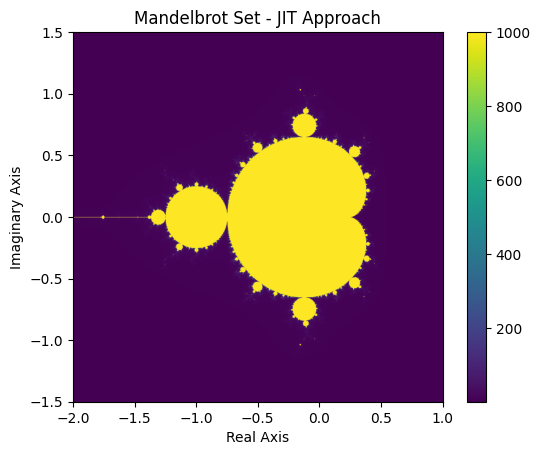

In [23]:
# Plotting the JIT set using colorbar.
plt.imshow(mandelbrot_set_jit, extent=(x_min, x_max, y_min, y_max))
plt.colorbar()
plt.title("Mandelbrot Set - JIT Approach")
plt.xlabel("Real Axis")
plt.ylabel("Imaginary Axis")
plt.show()